In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
# Load dataset
df = pd.read_csv(r"D:\Code_Alpha_projects\Unemployment in India.csv", skipinitialspace=True)

In [6]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

In [8]:
# Remove completely blank rows
df = df.dropna(how="all")

In [9]:
# Display basic information
print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

Dataset shape: (740, 7)
           Region        Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh  31-05-2019   Monthly                             3.65   
1  Andhra Pradesh  30-06-2019   Monthly                             3.05   
2  Andhra Pradesh  31-07-2019   Monthly                             3.75   
3  Andhra Pradesh  31-08-2019   Monthly                             3.32   
4  Andhra Pradesh  30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):

In [10]:
# Convert date column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [11]:
# Convert numeric columns
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [12]:
# Remove rows with missing important values
df = df.dropna(subset=[
    "Region",
    "Date",
    "Estimated Unemployment Rate (%)",
    "Area"
])

In [13]:
# Remove duplicate records
df = df.drop_duplicates()
print("Cleaned dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Cleaned dataset shape: (740, 7)

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate rows: 0


In [14]:
print(df.describe())

                             Date  Estimated Unemployment Rate (%)  \
count                         740                       740.000000   
mean   2019-12-12 18:36:58.378378                        11.787946   
min           2019-05-31 00:00:00                         0.000000   
25%           2019-08-31 00:00:00                         4.657500   
50%           2019-11-30 00:00:00                         8.350000   
75%           2020-03-31 00:00:00                        15.887500   
max           2020-06-30 00:00:00                        76.740000   
std                           NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500  
50%          4.744178e+0

In [15]:
print("\nStates in the dataset:")
print(df["Region"].nunique())
print("\nAreas:")
print(df["Area"].value_counts())
print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())


States in the dataset:
28

Areas:
Area
Urban    381
Rural    359
Name: count, dtype: int64

Date range:
2019-05-31 00:00:00 to 2020-06-30 00:00:00


Questions for your EDA
Which states have the highest average unemployment rate?
Is unemployment higher in rural or urban areas?
How did unemployment change from 2019 to 2020?
Which states experienced the largest unemployment increase?
Is there a relationship between unemployment rate and labour participation rate?
Which month had the highest average unemployment rate?
Does the number of employed people decrease when the unemployment rate increases?

Analysis 1: Average unemployment by state

In [16]:
state_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)
print(state_unemployment.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


['monthly_trend.png', 'rural_vs_urban.png', 'unemployment_by_state.png']


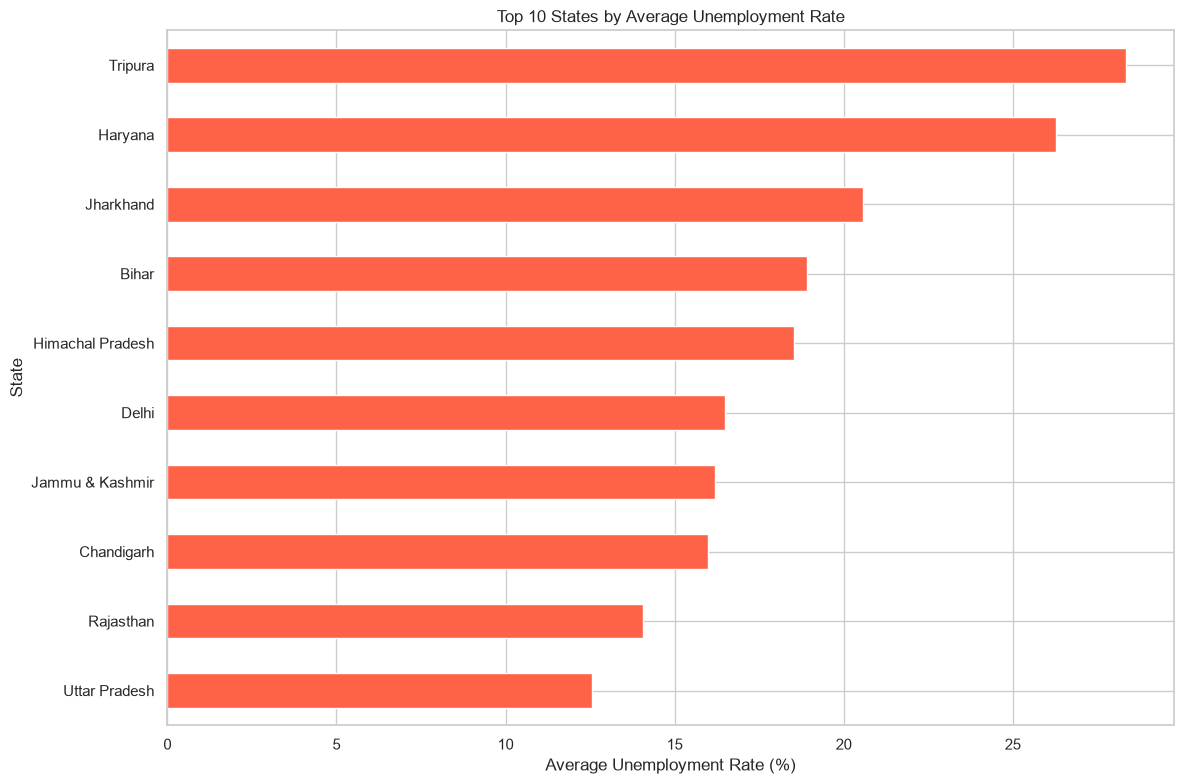

In [31]:
plt.figure(figsize=(12, 8))
state_unemployment.head(10).sort_values().plot(
    kind="barh",
    color="tomato"
)
import os
print(os.listdir("outputs"))
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("outputs/unemployment_by_state.png", dpi=300)
plt.show()

Analysis 2: Rural versus urban unemployment

In [22]:
area_unemployment = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)
print(area_unemployment)

Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64


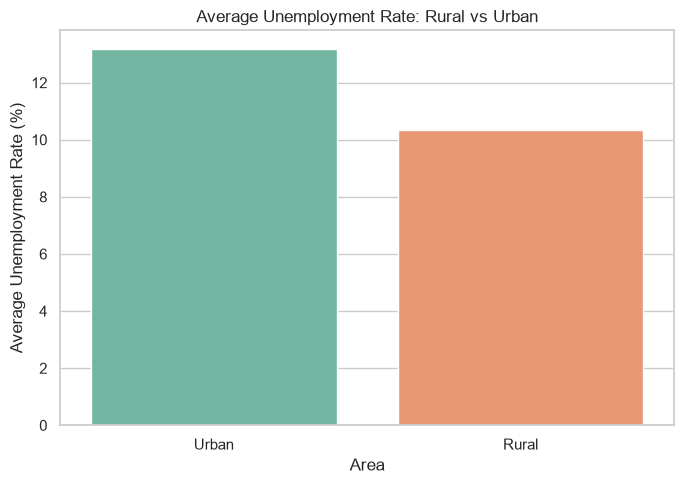

In [29]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=area_unemployment.index,
    y=area_unemployment.values,
    hue=area_unemployment.index,
    palette="Set2",
    legend=False
)
plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("outputs/rural_vs_urban.png", dpi=300)
plt.show()

Analysis 3: Monthly unemployment trend

In [25]:
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

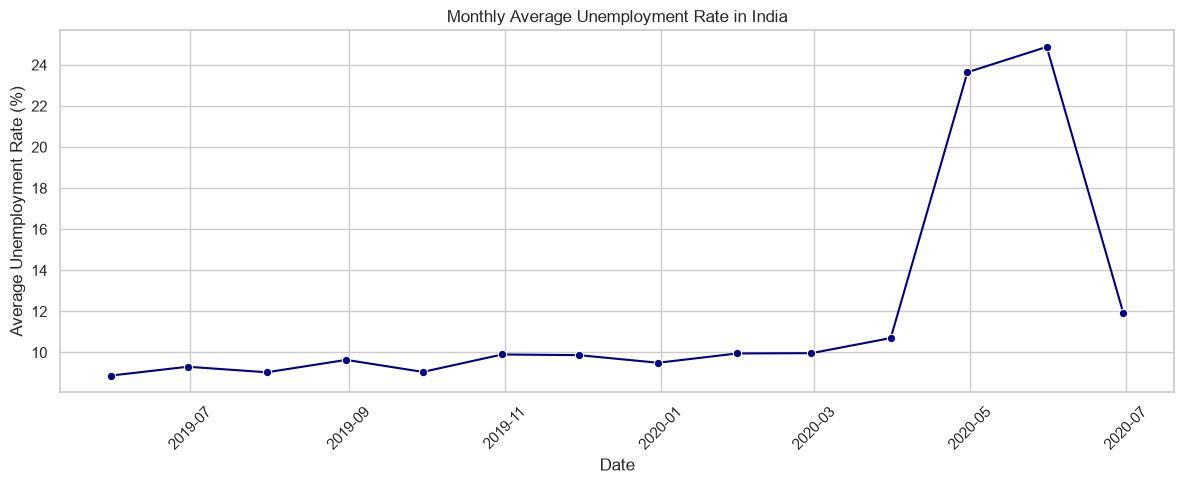

In [28]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o",
    color="darkblue"
)
plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/monthly_trend.png", dpi=300)
plt.show()


In [32]:
state_area = (
    df.groupby(["Region", "Area"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

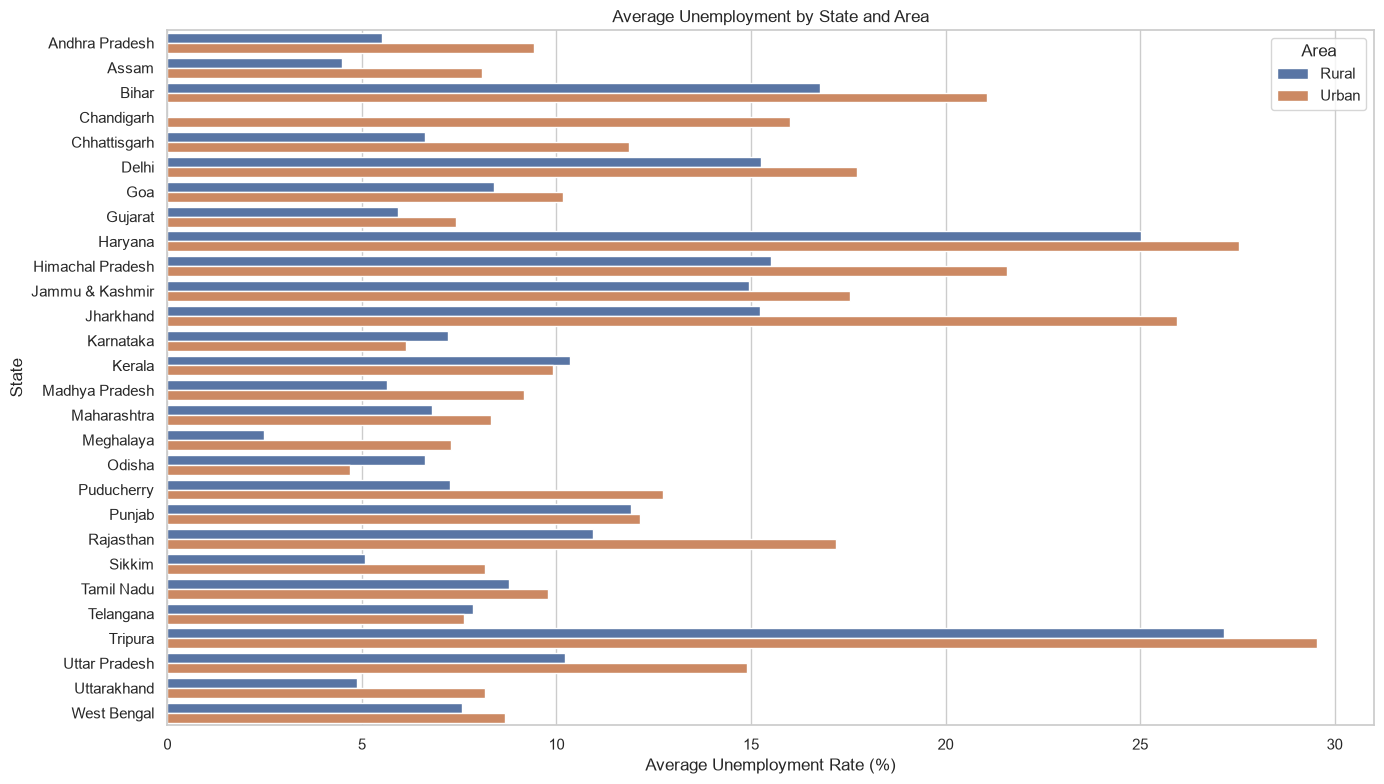

In [33]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=state_area,
    x="Estimated Unemployment Rate (%)",
    y="Region",
    hue="Area"
)
plt.title("Average Unemployment by State and Area")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Analysis 5: Correlation analysis

In [34]:
correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

In [35]:
correlation_matrix = df[correlation_columns].corr()

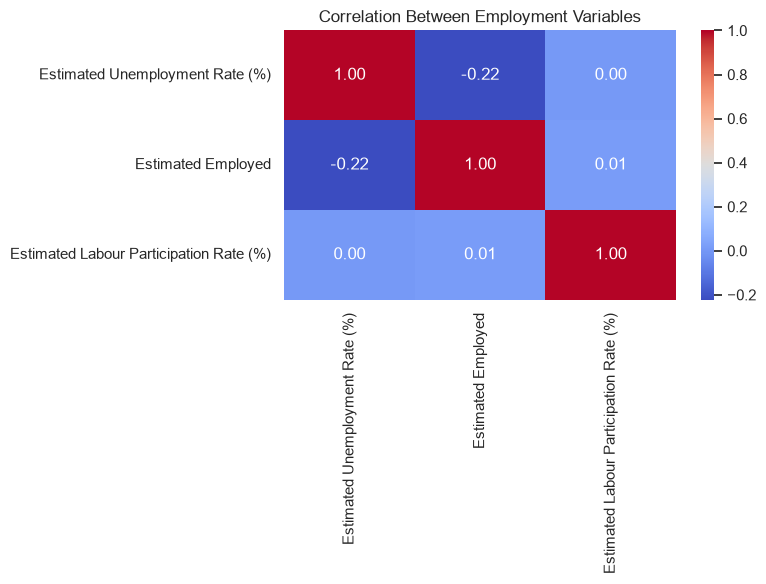

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Variables")
plt.tight_layout()
plt.show()

Analysis 6: Outlier detection

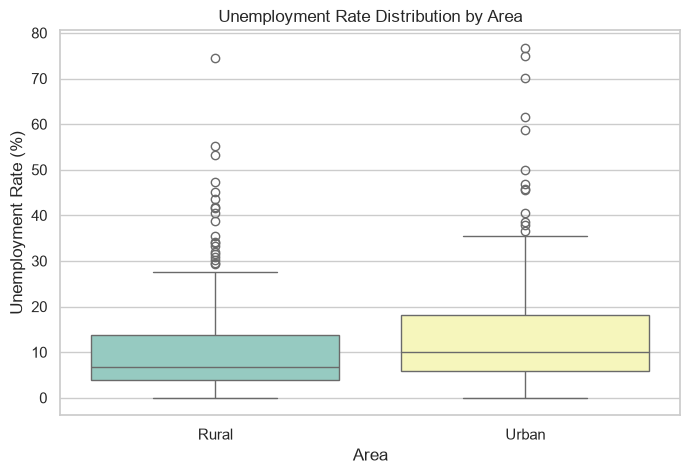

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)",
    hue="Area",
    palette="Set3",
    legend=False
)

plt.title("Unemployment Rate Distribution by Area")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [38]:
highest_unemployment = df.sort_values(
    by="Estimated Unemployment Rate (%)",
    ascending=False
)

print(highest_unemployment[
    [
        "Region",
        "Date",
        "Area",
        "Estimated Unemployment Rate (%)"
    ]
].head(10))

               Region       Date   Area  Estimated Unemployment Rate (%)
627        Puducherry 2020-04-30  Urban                            76.74
628        Puducherry 2020-05-31  Urban                            75.00
242        Puducherry 2020-04-30  Rural                            74.51
531         Jharkhand 2020-05-31  Urban                            70.17
530         Jharkhand 2020-04-30  Urban                            61.48
412             Bihar 2020-04-30  Urban                            58.77
145         Jharkhand 2020-05-31  Rural                            55.10
287        Tamil Nadu 2020-04-30  Rural                            53.19
507  Himachal Pradesh 2020-05-31  Urban                            50.00
38              Bihar 2020-05-31  Rural                            47.26
